## Задание 1

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

pd.set_option('display.float_format', '{:,.2f}'.format)

data = pd.read_csv('electronic_devices_sales.csv', parse_dates=['Purchase Date'])
data['Payment Method'] = data['Payment Method'].replace({'Paypal': 'PayPal'})
sales = data.loc[data['Order Status'].eq('Completed')].copy()
sales['Order Total'] = sales['Total Price'] + sales['Add-on Total']

In [2]:
customers = sales.groupby('Customer ID').agg(
    preferred_payment=('Payment Method', lambda methods: ', '.join(methods.mode())),
    product_spending=('Total Price', 'sum'),
    addon_spending=('Add-on Total', 'sum'),
    total_spending=('Order Total', 'sum')
)

customers = customers.reindex(sorted(data['Customer ID'].unique()))
customers['preferred_payment'] = customers['preferred_payment'].fillna('Нет завершённых покупок')
amount_columns = ['product_spending', 'addon_spending', 'total_spending']
customers[amount_columns] = customers[amount_columns].fillna(0).round(2)
customers.columns = ['Предпочитаемая оплата', 'Траты на товары', 'Траты на дополнения', 'Общие траты']
customers.to_csv('customer_summary.csv', encoding='utf-8-sig')
customers

,Предпочитаемая оплата,Траты на товары,Траты на дополнения,Общие траты
Customer ID,,,,
1000,PayPal,741.09,26.09,767.18
1002,"Cash, Credit Card","5,020.60",60.16,"5,080.76"
1003,Cash,41.50,35.56,77.06
1004,Credit Card,83.00,65.78,148.78
1005,"Debit Card, PayPal","11,779.11",75.33,"11,854.44"
...,...,...,...,...
19994,Нет завершённых покупок,0.00,0.00,0.00
19995,Credit Card,"5,394.56",0.00,"5,394.56"
19996,Bank Transfer,"12,063.02",198.98,"12,262.00"


## Задание 2

In [3]:
shipping_revenue = sales.groupby('Shipping Type')['Order Total'].sum().round(2).sort_values(ascending=False)
product_revenue = sales.groupby('Product Type')['Order Total'].sum().round(2).sort_values(ascending=False)
monthly_addons = sales.groupby(sales['Purchase Date'].dt.to_period('M'))['Add-on Total'].sum().round(2).sort_index()
quarterly_addons = sales.groupby(sales['Purchase Date'].dt.to_period('Q'))['Add-on Total'].sum().round(2).sort_index()

for title, result in [
    ('Доход по методу доставки', shipping_revenue),
    ('Доход по типу продукта', product_revenue),
    ('Доход от дополнений по месяцам', monthly_addons),
    ('Доход от дополнений по кварталам', quarterly_addons)
]:
    print(title)
    print(result.to_string())
    print()

Доход по методу доставки
Shipping Type
Standard    14,676,351.95
Expedited    8,610,437.09
Same Day     8,469,574.60
Overnight    5,982,983.40
Express      5,725,863.77

Доход по типу продукта
Product Type
Smartphone   14,630,325.53
Smartwatch    9,557,416.02
Laptop        8,536,583.03
Tablet        7,893,431.51
Headphones    2,847,454.72

Доход от дополнений по месяцам
Purchase Date
2023-09    5,337.61
2023-10   26,153.21
2023-11   24,453.33
2023-12   22,750.23
2024-01   93,254.95
2024-02   80,253.72
2024-03   84,713.93
2024-04   82,294.06
2024-05   89,374.18
2024-06   84,648.60
2024-07   88,811.55
2024-08   87,861.11
2024-09   65,688.76
Freq: M

Доход от дополнений по кварталам
Purchase Date
2023Q3     5,337.61
2023Q4    73,356.77
2024Q1   258,222.60
2024Q2   256,316.84
2024Q3   242,361.42
Freq: Q-DEC



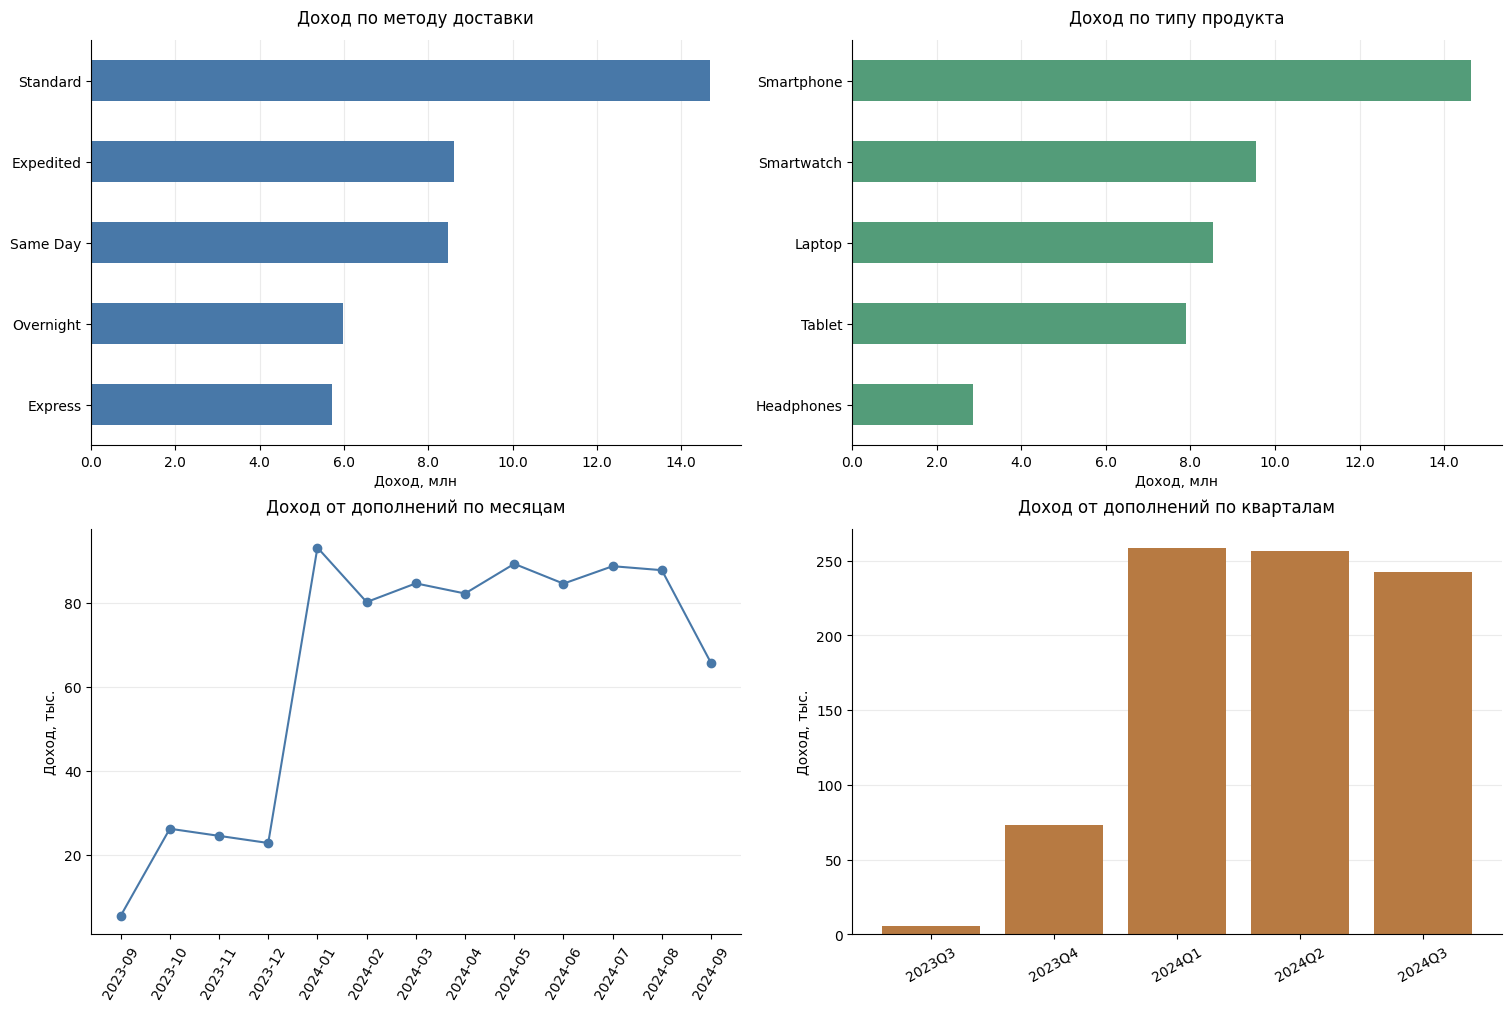

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10), layout='constrained')

shipping_revenue.sort_values().plot.barh(ax=axes[0, 0], color='#4878A8')
product_revenue.sort_values().plot.barh(ax=axes[0, 1], color='#539C79')
axes[1, 0].plot(monthly_addons.index.astype(str), monthly_addons.values, marker='o', color='#4878A8')
axes[1, 1].bar(quarterly_addons.index.astype(str), quarterly_addons.values, color='#B77A42')

for ax, title in zip(axes.flat, [
    'Доход по методу доставки',
    'Доход по типу продукта',
    'Доход от дополнений по месяцам',
    'Доход от дополнений по кварталам'
]):
    ax.set_title(title, pad=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_axisbelow(True)

for ax in axes[0]:
    ax.xaxis.set_major_formatter(FuncFormatter(lambda value, position: f'{value / 1_000_000:.1f}'))
    ax.set_xlabel('Доход, млн')
    ax.grid(axis='x', alpha=0.25)

for ax in axes[1]:
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, position: f'{value / 1_000:.0f}'))
    ax.set_ylabel('Доход, тыс.')
    ax.grid(axis='y', alpha=0.25)

axes[1, 0].tick_params(axis='x', rotation=60)
axes[1, 1].tick_params(axis='x', rotation=30)
fig.savefig('revenue.png', dpi=160)
plt.show()